0**. Conectar drive y librerias**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

In [ ]:
df_ = pd.read_excel('/content/drive/MyDrive/Analisis y Predicción de series de tiempo/energy.xlsx')
df_.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Analisis y Predicción de series de tiempo/energy.xlsx'

In [ ]:
df = df_

In [ ]:

# Convertir fechas
df['DateUTC'] = pd.to_datetime(df['DateUTC'])
df['TimeFrom'] = pd.to_datetime(df['TimeFrom']).dt.time

# Crear datetime completo
df['datetime'] = df.apply(lambda x: pd.Timestamp.combine(x['DateUTC'], x['TimeFrom']), axis=1)

# Ordenar e indexar
df = df.sort_values('datetime')
df.set_index('datetime', inplace=True)

# Quedarnos con lo necesario
df = df[['Value', 'clima', 'CountryCode' ]]
df = df.dropna()

# 2. Análisis preliminar

# 2.1 Inspección general

In [ ]:
print('Column names:', df.columns)
df.head()

Column names: Index(['Value', 'clima', 'CountryCode'], dtype='object')


,Value,clima,CountryCode
datetime,,,
2023-01-01,776.50,frio,EE
2023-01-01,3987.00,caliente,GR
2023-01-01,1521.25,caliente,HR
2023-01-01,978.87,frio,LT
2023-01-01,19251.00,caliente,ES


**Dimenciones del conjunto de datos**

In [ ]:
#Número de observaciones y variables
print('No. of rows, columns:', df.shape)

No. of rows, columns: (270770, 3)


**Primeros y últimos valores**

In [ ]:
# Revisar extremos
df.head()
df.tail()

,Value,clima,CountryCode
datetime,,,
2025-12-31 23:00:00,4968.750000,caliente,GR
2025-12-31 23:00:00,1458.005805,frio,LT
2025-12-31 23:00:00,6186.400000,caliente,PT
2025-12-31 23:00:00,16310.250000,frio,SE
2025-12-31 23:00:00,23799.000000,caliente,ES


In [ ]:
# Rango temporal
df.index.min(), df.index.max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2025-12-31 23:00:00'))

In [ ]:
# Frecuencia
df.index.to_series().diff().value_counts()

,count
datetime,
0 days 00:00:00,244466
0 days 01:00:00,26303


**Identificación y manejo de datos faltantes**

In [ ]:
#Porcentajes de datos faltantes
(df.isna().mean() * 100).sort_values(ascending=False)

,0
Value,0.0
clima,0.0
CountryCode,0.0


In [ ]:
df = df.reset_index()
df['datetime'] = pd.to_datetime(df['datetime'])
full_range = pd.date_range(df['datetime'].min(), df['datetime'].max(), freq='H')

/tmp/ipykernel_20365/2526658733.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(df['datetime'].min(), df['datetime'].max(), freq='H')


In [ ]:
missing_by_country = {}

for pais in df['CountryCode'].unique():
    fechas_pais = df[df['CountryCode'] == pais]['datetime']
    missing = full_range.difference(fechas_pais)
    missing_by_country[pais] = len(missing)

missing_by_country


{'EE': 9,
 'GR': 3,
 'HR': 0,
 'LT': 0,
 'ES': 0,
 'LV': 0,
 'NO': 0,
 'PT': 0,
 'SE': 0,
 'FI': 0,
 'CY': 18562}

In [ ]:
#Por amplio periodo sin datos, retiramos el país CY
df = df[df['CountryCode'] != 'CY']

In [ ]:
#Por la falta de pocos datos en los paises (EE=9, GR=3) se hace interpolación
df = df.sort_values(['CountryCode', 'datetime'])

df['Value'] = df.groupby('CountryCode')['Value'].transform(lambda x: x.interpolate())

In [ ]:
df.isna().sum()

,0
datetime,0
Value,0
clima,0
CountryCode,0


**Estadísticas descriptivas**

**1. Por clima**

In [ ]:
df.groupby('clima')['Value'].describe()

,count,mean,std,min,25%,50%,75%,max
clima,,,,,,,,
caliente,105213.0,10055.672719,9946.683481,90.3,3231.0,5677.1,10967.0,39696.0
frio,157815.0,7135.565588,6714.618967,412.3,957.0,5333.8,12729.0,25756.0


**2.Por clima y país**

In [ ]:
df.groupby(['clima', 'CountryCode'])['Value'].describe()

count          mean          std      min  \
clima    CountryCode                                                
caliente ES           26304.0  26611.637774  4261.014392  4707.00   
         GR           26301.0   5646.208072  1277.773245  2730.00   
         HR           26304.0   2066.634628   399.165837  1140.50   
         PT           26304.0   5897.707497  1062.622128    90.30   
frio     EE           26295.0    911.128002   195.677582   412.30   
         FI           26304.0   9331.835873  1583.476685  5273.15   
         LT           26304.0   1355.184237   259.522908   718.03   
         LV           26304.0    785.040223   158.150366   423.00   
         NO           26304.0  15524.705739  3114.565361  9608.24   
         SE           26304.0  14903.369740  3185.812411  8259.00   

                               25%          50%         75%       max  
clima    CountryCode                                                   
caliente ES           23120.750000  26614.00000  29685.0000  39696.00  
         GR            4674.000000   5529.00000   6363.0000  11034.00  
         HR            1753.437500   2061.62500   2349.0000   3363.00  
         PT            5001.975000   5868.15000   6631.4250   9704.90  
frio     EE             763.700000    890.40000   1050.9000   1607.00  
         FI            8135.643750   9159.08750  10476.1250  14992.75  
         LT            1148.437500   1338.06000   1532.2975   2280.30  
         LV             658.817500    779.75000    902.0000   1243.00  
         NO           12856.638125  15168.57375  18031.8875  24929.73  
         SE           12355.750000  14394.50000  17263.0000  25756.00

**Estatisticos de disperción por paises**

In [ ]:
df_dispersion = df.groupby('CountryCode')['Value'].agg([
    'mean',
    'std',
    'var',
    'min',
    'max'
])

df_dispersion['range'] = df_dispersion['max'] - df_dispersion['min']
df_dispersion['cv'] = df_dispersion['std'] / df_dispersion['mean']

df_dispersion

,mean,std,var,min,max,range,cv
CountryCode,,,,,,,
EE,911.128002,195.677582,3.828972e+04,412.30,1607.00,1194.70,0.214764
ES,26611.637774,4261.014392,1.815624e+07,4707.00,39696.00,34989.00,0.160118
FI,9331.835873,1583.476685,2.507398e+06,5273.15,14992.75,9719.60,0.169685
GR,5646.208072,1277.773245,1.632704e+06,2730.00,11034.00,8304.00,0.226306
HR,2066.634628,399.165837,1.593334e+05,1140.50,3363.00,2222.50,0.193148
LT,1355.184237,259.522908,6.735214e+04,718.03,2280.30,1562.27,0.191504
LV,785.040223,158.150366,2.501154e+04,423.00,1243.00,820.00,0.201455
NO,15524.705739,3114.565361,9.700517e+06,9608.24,24929.73,15321.49,0.200620
PT,5897.707497,1062.622128,1.129166e+06,90.30,9704.90,9614.60,0.180175


A pesar de las marcadas diferencias en niveles absolutos de consumo eléctrico entre países, la dispersión relativa (medida a través del coeficiente de variación) resulta relativamente homogénea. Esto sugiere la existencia de patrones estructurales comunes en la dinámica de la demanda energética.

*consulta al profesor: por las diferencias en escala sería necesario normalizar los datos para evitar sesgos en el modelo (que el modelo se guíe por países con niveles absolutos grandes).*

# 3. Análisis de la serie

**Visualización temporal**

In [ ]:
import matplotlib.pyplot as plt

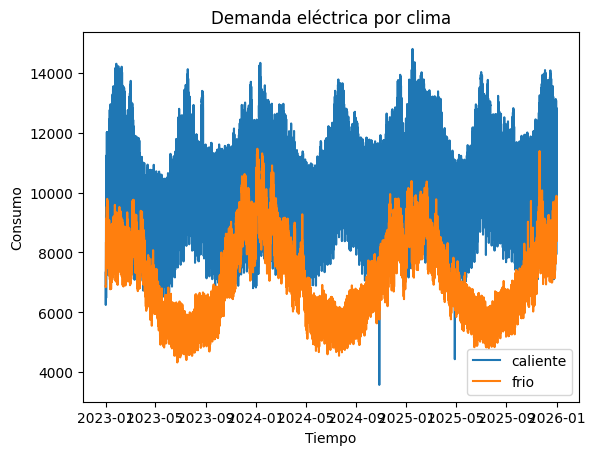

In [ ]:
#grafico por clima
df_clima = df.groupby(['datetime', 'clima'])['Value'].mean().reset_index()

for clima in df_clima['clima'].unique():
    subset = df_clima[df_clima['clima'] == clima]
    plt.plot(subset['datetime'], subset['Value'], label=clima)

plt.legend()
plt.title('Demanda eléctrica por clima')
plt.xlabel('Tiempo')
plt.ylabel('Consumo')
plt.show()

<Figure size 1200x500 with 0 Axes>

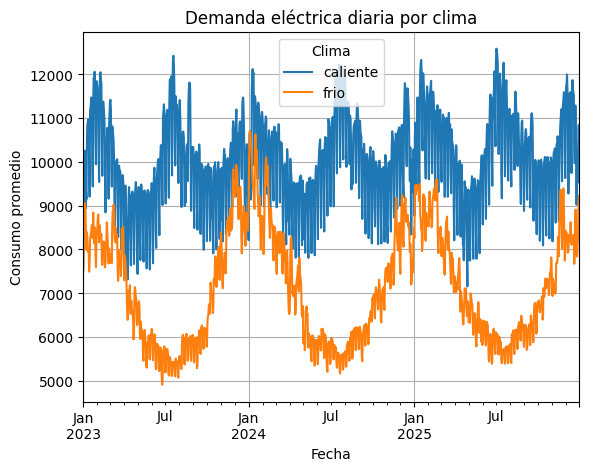

In [ ]:
# 2. Agregar por clima y fecha (promedio)
df_daily = df.groupby(['datetime', 'clima'])['Value'].mean().reset_index()

# 3. Pasar a frecuencia diaria
df_daily = df_daily.set_index('datetime').groupby('clima').resample('D').mean().reset_index()

# 4. Convertir a formato pivot (para graficar fácil)
df_pivot = df_daily.pivot(index='datetime', columns='clima', values='Value')

# 5. Graficar
plt.figure(figsize=(12,5))
df_pivot.plot()

plt.title('Demanda eléctrica diaria por clima')
plt.xlabel('Fecha')
plt.ylabel('Consumo promedio')
plt.grid(True)
plt.legend(title='Clima')

plt.show()

<Figure size 1200x500 with 0 Axes>

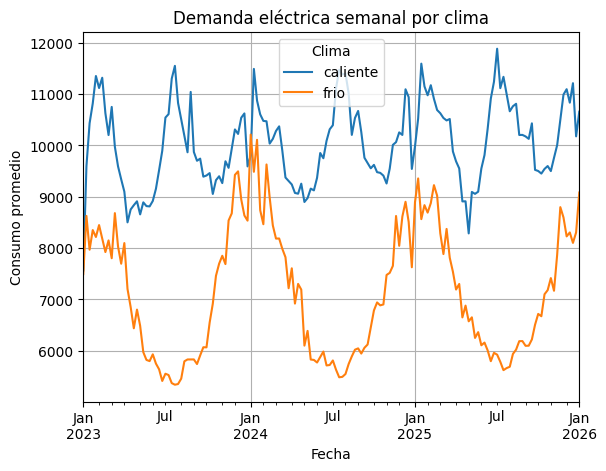

In [ ]:
# 2. Agregar por clima y fecha (promedio)
df_daily = df.groupby(['datetime', 'clima'])['Value'].mean().reset_index()

# 3. Pasar a frecuencia diaria
df_daily = df_daily.set_index('datetime').groupby('clima').resample('W').mean().reset_index()

# 4. Convertir a formato pivot (para graficar fácil)
df_pivot = df_daily.pivot(index='datetime', columns='clima', values='Value')

# 5. Graficar
plt.figure(figsize=(12,5))
df_pivot.plot()

plt.title('Demanda eléctrica semanal por clima')
plt.xlabel('Fecha')
plt.ylabel('Consumo promedio')
plt.grid(True)
plt.legend(title='Clima')

plt.show()

<Figure size 1200x500 with 0 Axes>

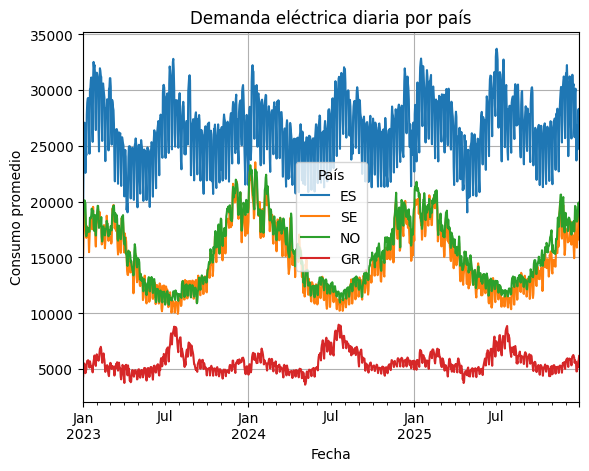

In [ ]:

# 2. Agregar por país y fecha (promedio)
df_daily = df.groupby(['datetime', 'CountryCode'])['Value'].mean().reset_index()

# 3. Pasar a frecuencia diaria (resample correcto por país)
df_daily = df_daily.set_index('datetime').groupby('CountryCode').resample('D').mean().reset_index()

# 4. Pivot para graficar
df_pivot = df_daily.pivot(index='datetime', columns='CountryCode', values='Value')

# 5. (Opcional) seleccionar algunos países para no saturar el gráfico
paises = ['ES', 'SE', 'NO', 'GR']  # cambia según quieras
df_pivot = df_pivot[paises]

# 6. Graficar
plt.figure(figsize=(12,5))
df_pivot.plot()

plt.title('Demanda eléctrica diaria por país')
plt.xlabel('Fecha')
plt.ylabel('Consumo promedio')
plt.grid(True)
plt.legend(title='País')

plt.show()

**Análisis de componentes**

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

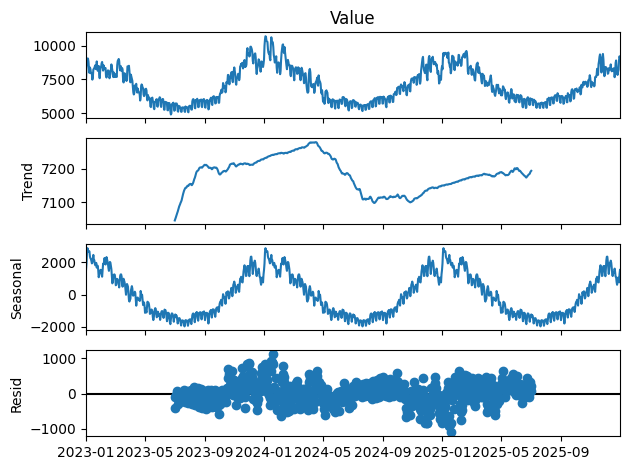

In [ ]:
# Clima frio
df_clima['datetime'] = pd.to_datetime(df_clima['datetime'])

serie = df_clima[df_clima['clima'] == 'frio']
serie = serie.set_index('datetime')['Value']

# Asegurar frecuencia diaria (si ya hiciste resample antes, mejor)
serie = serie.resample('D').mean()

# Descomposición
result = seasonal_decompose(serie, model='additive', period=365)

# Graficar
result.plot()
plt.show()

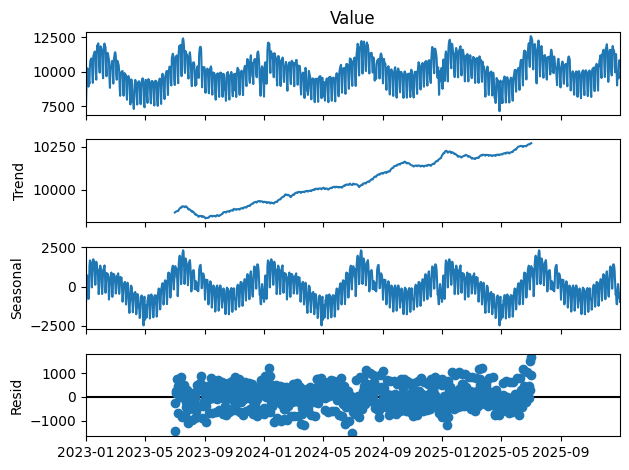

In [ ]:
# clima caliente
df_clima['datetime'] = pd.to_datetime(df_clima['datetime'])

serie = df_clima[df_clima['clima'] == 'caliente']
serie = serie.set_index('datetime')['Value']

# Asegurar frecuencia diaria (si ya hiciste resample antes, mejor)
serie = serie.resample('D').mean()

# Descomposición
result = seasonal_decompose(serie, model='additive', period=365)

# Graficar
result.plot()
plt.show()

**Detección de outliers**

In [ ]:
def detect_outliers_iqr(x):
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (x < lower) | (x > upper)

df['outlier_iqr'] = df.groupby('CountryCode')['Value'].transform(detect_outliers_iqr)

In [ ]:
df['outlier_iqr'].sum()

np.int64(734)

In [ ]:
df.groupby('CountryCode')['outlier_iqr'].sum()

,outlier_iqr
CountryCode,
EE,45
ES,7
FI,71
GR,509
HR,24
LT,23
LV,0
NO,0
PT,43


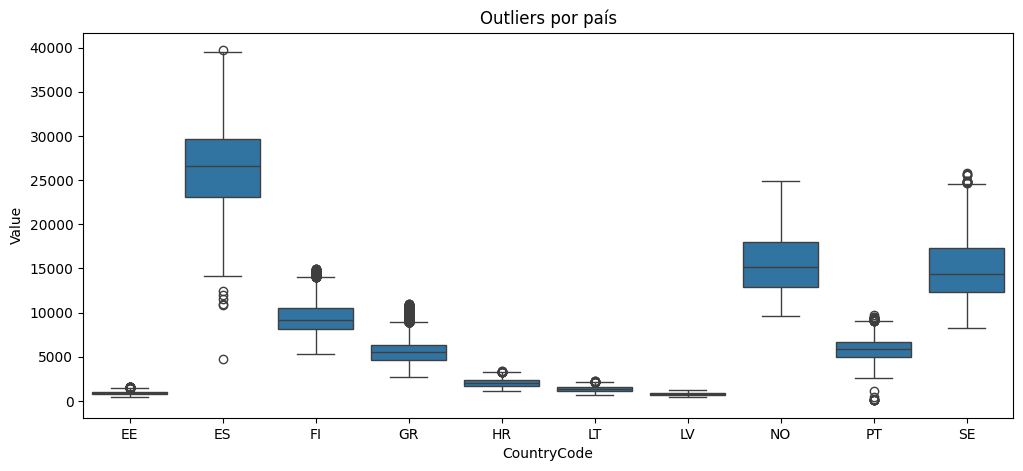

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='CountryCode', y='Value')
plt.title('Outliers por país')
plt.show()

*Pregunta para el profesor: sería lo correcto eliminar los outliers? puesto que podrían representar cosas como "golpes de calor/frio" que sería información importante para la predicción, no?*

## 4. Estacionalidad y periodicidad

### 4.1 Análisis de patrones recurrentes
ACF y PACF

<Figure size 1200x500 with 0 Axes>

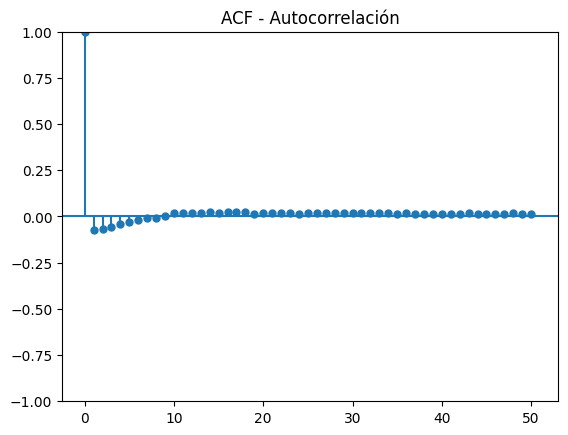

<Figure size 1200x500 with 0 Axes>

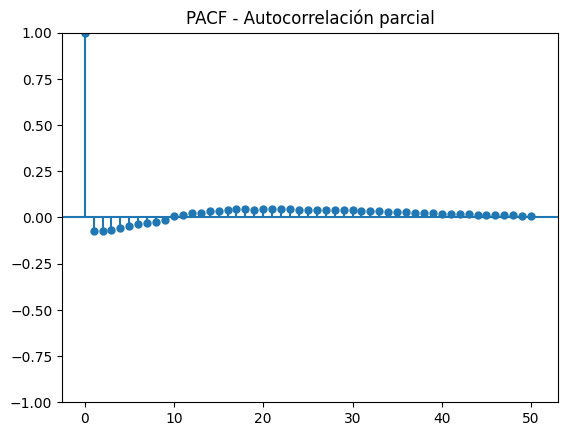

In [ ]:
plt.figure(figsize=(12,5))
plot_acf(df['Value'], lags=50)
plt.title("ACF - Autocorrelación")
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(df['Value'], lags=50)
plt.title("PACF - Autocorrelación parcial")
plt.show()

In [ ]:
df['hour'] = df.index.hour

plt.figure(figsize=(12,6))
sns.boxplot(x='hour', y='Value', data=df)
plt.title("Consumo por hora del día")
plt.show()

In [ ]:
df['day'] = df.index.dayofweek

plt.figure(figsize=(12,6))
sns.boxplot(x='day', y='Value', data=df)
plt.title("Consumo por día de la semana")
plt.show()

In [ ]:
sns.boxplot(x='clima', y='Value', data=df)
plt.title("Consumo agrupado por paises por tipo de clima")
plt.show()

In [ ]:
daily = df['Value'].resample('D').mean()

plt.figure(figsize=(12,5))
daily.plot(title="Consumo promedio diario")
plt.show()

In [ ]:
monthly = df['Value'].resample('M').mean()

plt.figure(figsize=(12,5))
monthly.plot(title="Consumo promedio mensual")
plt.show()

/tmp/ipykernel_20365/2052108861.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['Value'].resample('M').mean()


TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'